# Practical 7: Random Forests, OOB Error, Bagging and Feature Subsampling

## Student Placement Prediction

### Aim
Implement and analyse Random Forests using **training and validation data**, study **OOB error convergence**, compare `max_features`, demonstrate **manual bootstrap bagging**, calculate **permutation importance**, and compare a Random Forest with a single Decision Tree.

### Key points
- **Decision Tree:** one person makes the decision.
- **Bagging:** ask many trees, each trained on a different bootstrap sample.
- **Random Forest:** many trees + bootstrap samples + random feature selection.
- **OOB:** students left out of a tree's bootstrap sample can help evaluate that tree.
- **Permutation importance:** shuffle one feature and see how much model accuracy changes.

### CSV
Use the same 14-row CSV from Practical 1 with columns:

`ID, CGPA, Internships, Backlogs, Aptitude, Placed`

Change `CSV_PATH` below if your filename is different.

> Because this teaching dataset has only 14 students, numerical results are for learning the algorithm and may be unstable.


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
from sklearn import datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets


from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)


In [4]:
# ============================================================
# 2. LOAD IRIS DATASET
# ============================================================



# Load the built-in Iris dataset
iris = datasets.load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(iris.feature_names)

print("\nTarget classes:")
print(iris.target_names)


Dataset shape: (150, 4)
Target shape: (150,)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes:
['setosa' 'versicolor' 'virginica']


In [5]:
# ============================================================
# 3. DEFINE FEATURES AND TARGET
# ============================================================

X = iris.data
y = iris.target

print("Features:")
for i, feature in enumerate(iris.feature_names):
    print(f"{i}: {feature}")

print("\nTarget classes:")
for i, target in enumerate(iris.target_names):
    print(f"{i}: {target}")

Features:
0: sepal length (cm)
1: sepal width (cm)
2: petal length (cm)
3: petal width (cm)

Target classes:
0: setosa
1: versicolor
2: virginica


In [ ]:
# ============================================================
# 5. DEFINE X AND y
# ============================================================

X = iris.data
y = iris.target

print("Features:", iris.feature_names)
print("Target: ", iris.target_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target:  ['setosa' 'versicolor' 'virginica']


In [6]:
# ============================================================
# 4. DISPLAY IRIS DATA
# ============================================================

iris_df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

iris_df["Target"] = y

iris_df["Species"] = iris_df["Target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

display(iris_df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target,Species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


## Step 1 — Training Data and Validation/Test Data

Think of it simply:

- **Training data:** the students the model learns from.
- **Validation/test data:** students kept aside to check performance on unseen data.

We use the same split throughout this practical so the models are compared fairly.


In [7]:
# ============================================================
# 5. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining class distribution:")
print(np.bincount(y_train))

print("\nValidation class distribution:")
print(np.bincount(y_val))

Training samples: 105
Validation samples: 45

Training class distribution:
[35 35 35]

Validation class distribution:
[15 15 15]


# Part A — Single Decision Tree Baseline

First build one Decision Tree. This is our baseline.

Then we will build a Random Forest and ask:

**Does many trees work better than one tree?**


In [8]:
# ============================================================
# 6. SINGLE DECISION TREE BASELINE
# ============================================================

dt_baseline = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_baseline.fit(X_train, y_train)

dt_train_pred = dt_baseline.predict(X_train)
dt_val_pred = dt_baseline.predict(X_val)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_val_acc = accuracy_score(y_val, dt_val_pred)

print("SINGLE DECISION TREE")
print("=" * 50)
print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")
print(f"Tree Depth          : {dt_baseline.get_depth()}")
print(f"Number of Leaves    : {dt_baseline.get_n_leaves()}")


SINGLE DECISION TREE
Training Accuracy   : 1.0000
Validation Accuracy : 0.8889
Tree Depth          : 6
Number of Leaves    : 8


# Part B — Random Forest

A Random Forest creates many Decision Trees.

Important parameters:

- `n_estimators` → number of trees.
- `bootstrap=True` → each tree gets a bootstrap sample.
- `oob_score=True` → calculate Out-of-Bag accuracy.
- `max_features` → random feature subsampling at each split.


In [9]:
# ============================================================
# 7. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("RANDOM FOREST")
print("=" * 50)
print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")

RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 1.0000
Validation Accuracy : 0.8889
OOB Accuracy        : 0.9524
OOB Error           : 0.0476


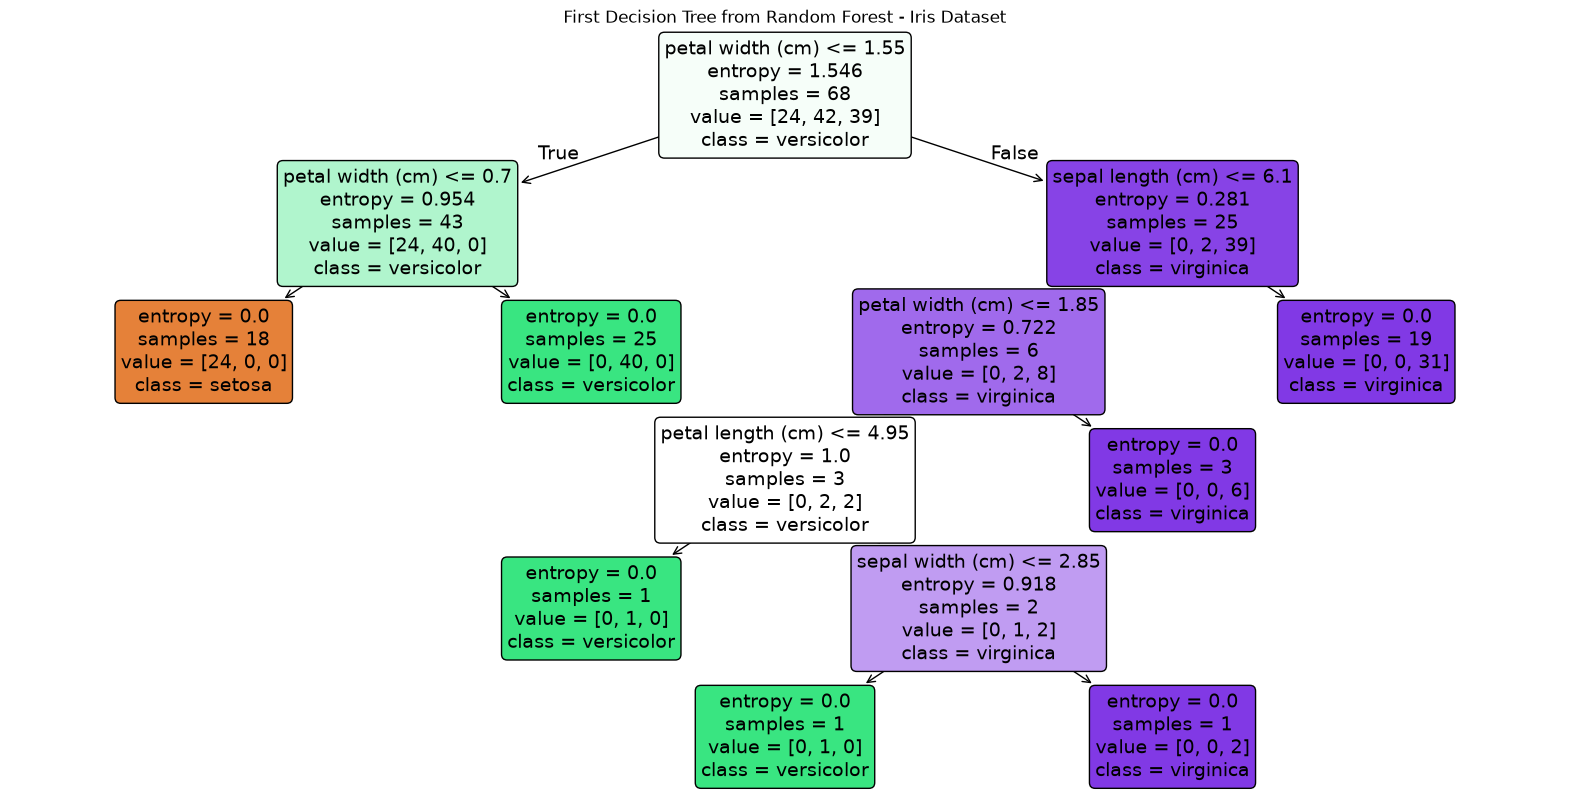

In [14]:
# ============================================================
# 8. TREE VISUALIZATION
# ============================================================
from sklearn.tree import DecisionTreeClassifier, plot_tree
feature_names = iris.feature_names
class_names = iris.target_names

plt.figure(figsize=(20, 10))

plot_tree(
    rf.estimators_[0],
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True
)

plt.title("First Decision Tree from Random Forest - Iris Dataset")
plt.show()

In [11]:
class_names=["Not Placed", "Placed"]

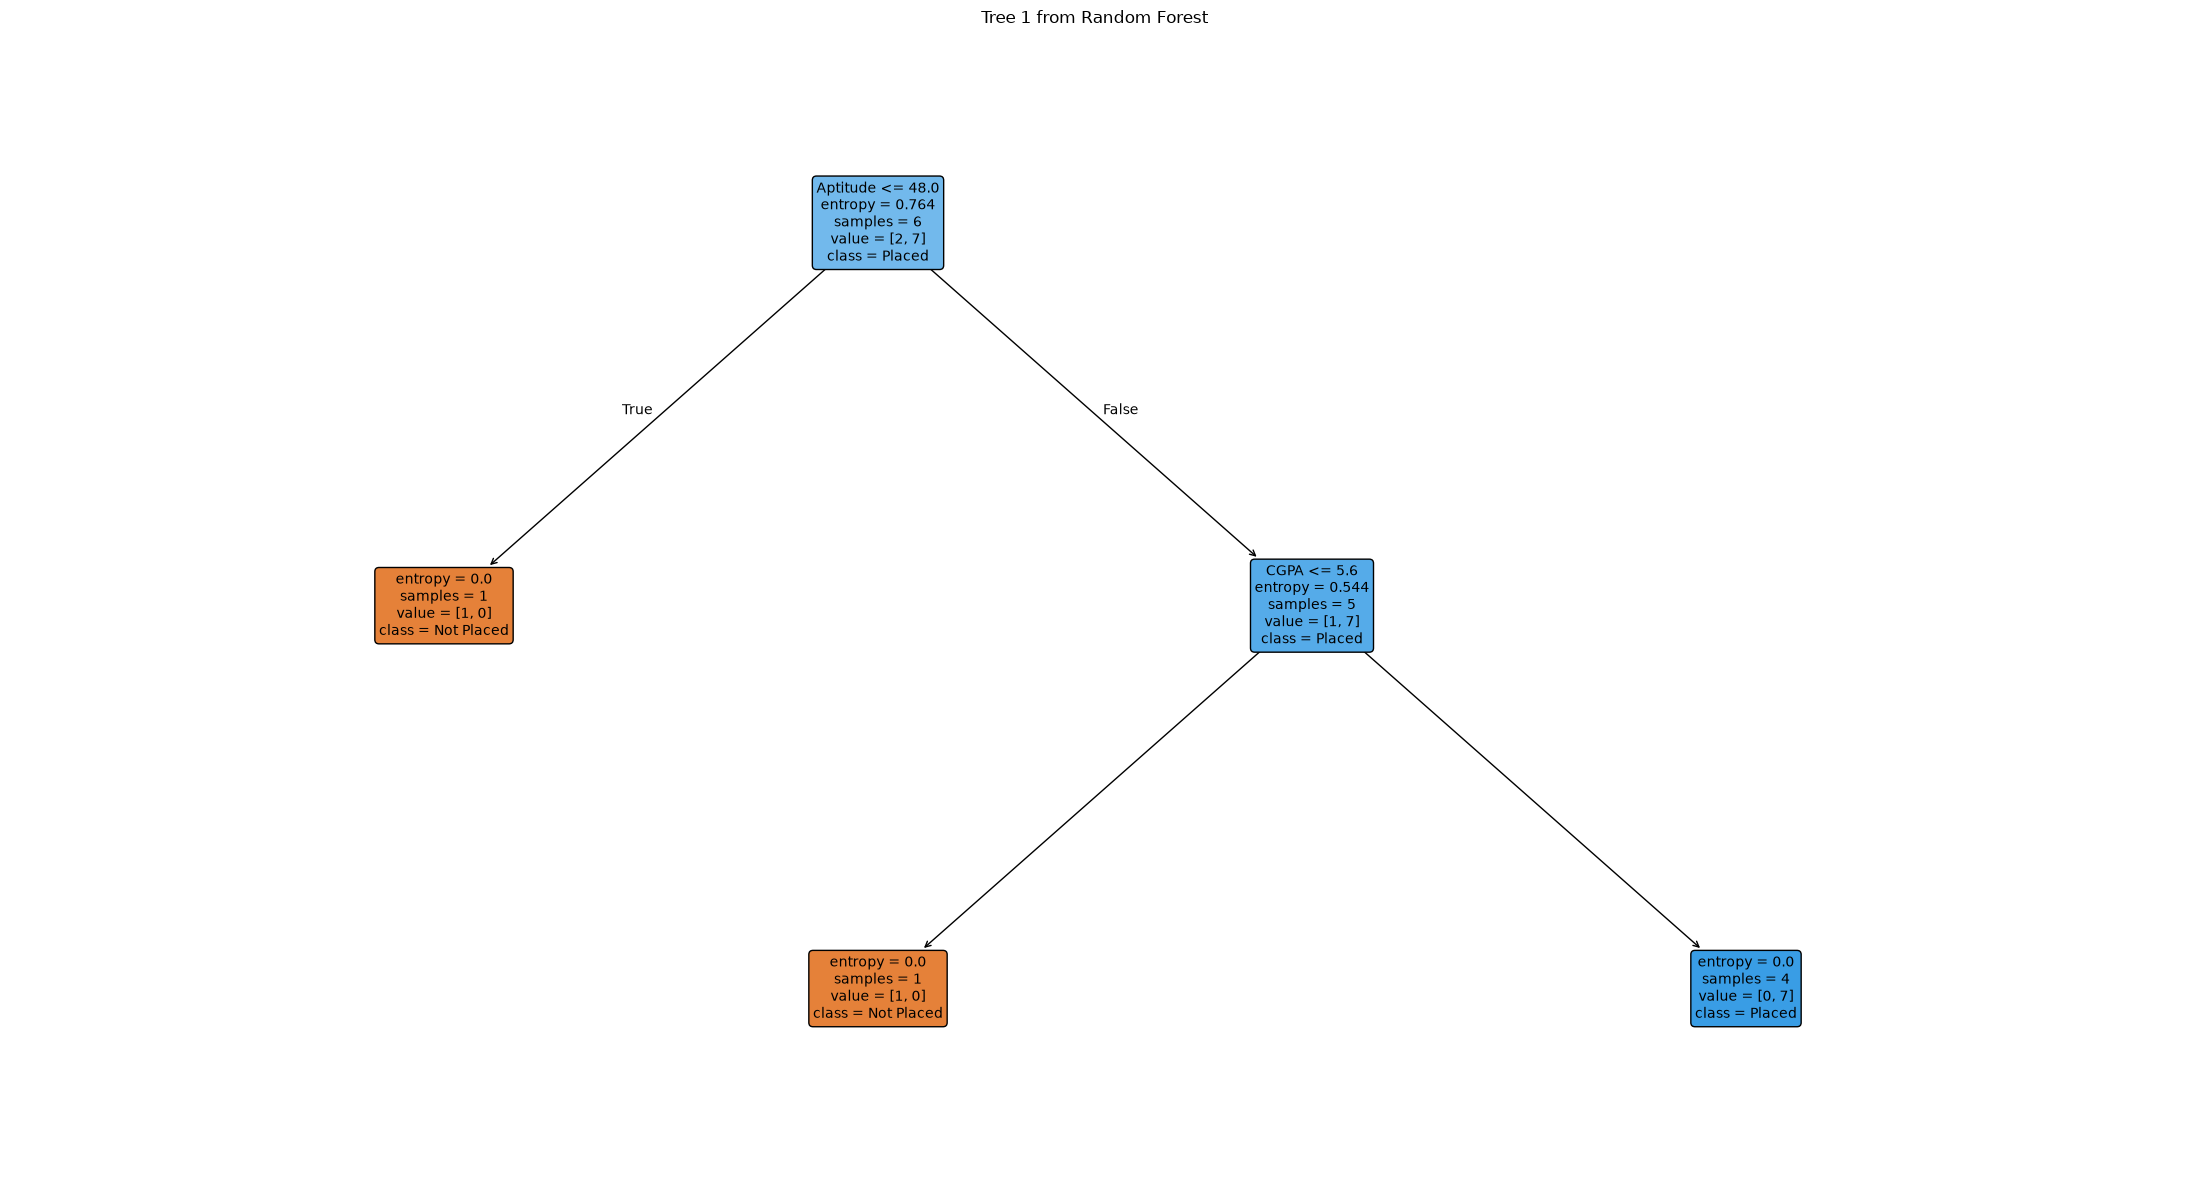

In [ ]:
# ============================================================
# IMPORT plot_tree
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tree 1 from Random Forest")
plt.tight_layout()
plt.show()

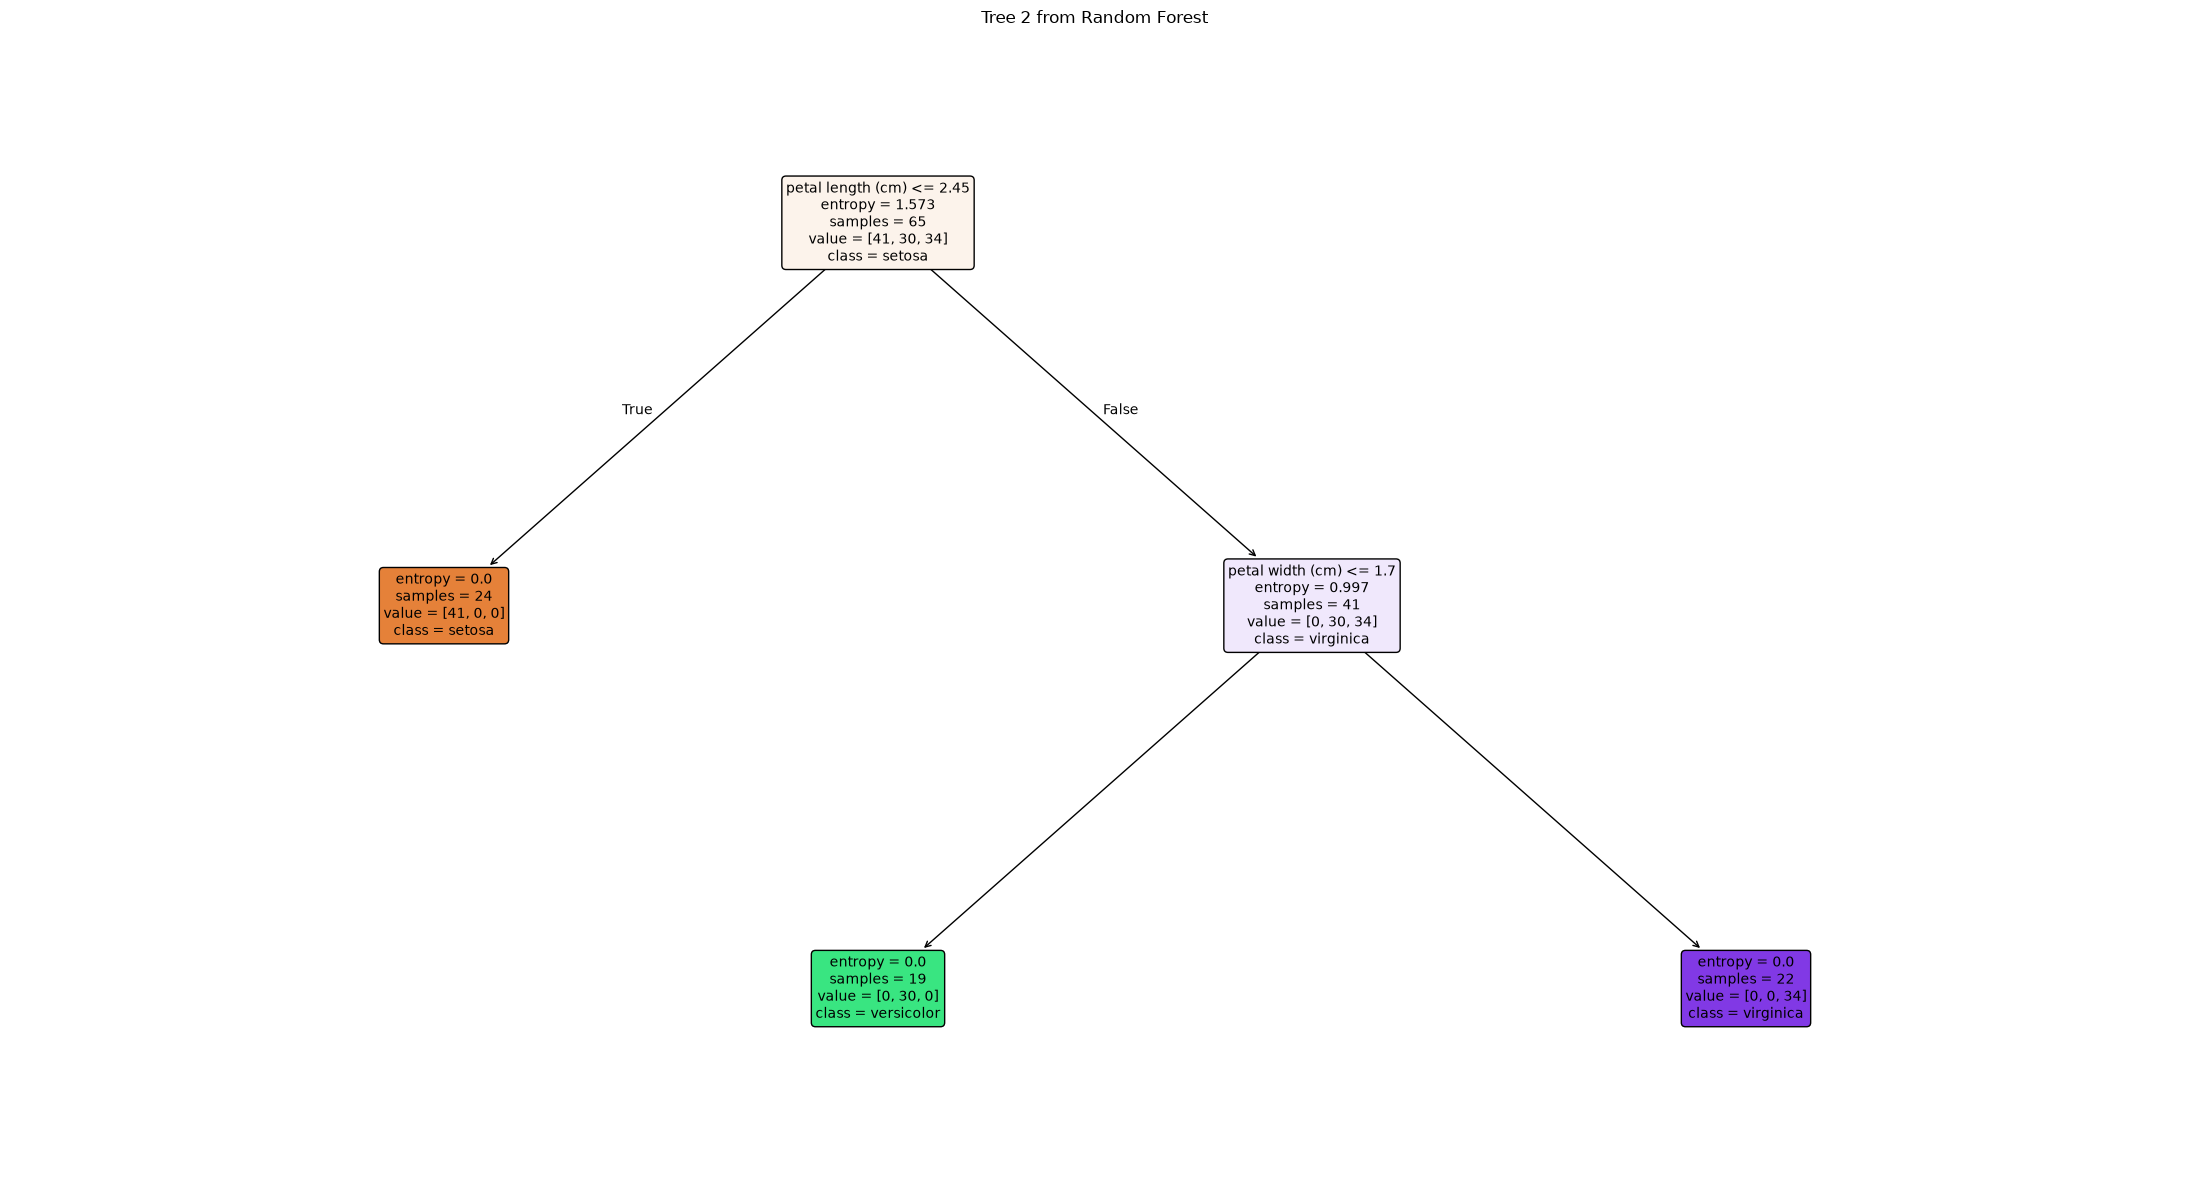

In [15]:
# ============================================================
# VISUALIZE SECOND TREE FROM RANDOM FOREST
# ============================================================

plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[1],
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tree 2 from Random Forest")
plt.tight_layout()
plt.show()

In [17]:
target_names=["Not Placed", "Placed"]

In [18]:
# ============================================================
# 9. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_val,
    rf_val_pred,
    target_names=iris.target_names,
    zero_division=0
))


RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



In [19]:
# ============================================================
# 9. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_val,
    rf_val_pred,
    target_names=iris.target_names,
    zero_division=0
))

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



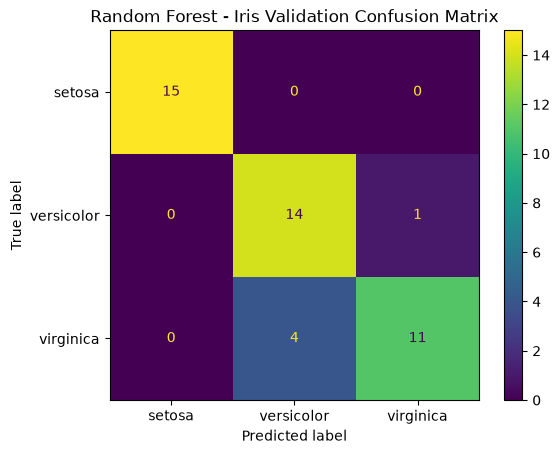

In [20]:

# ============================================================
# 10. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_val, rf_val_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
).plot()

plt.title("Random Forest - Iris Validation Confusion Matrix")
plt.show()

# Part C — OOB Error Convergence

For each tree, some training observations are not selected in its bootstrap sample. These are **Out-of-Bag (OOB)** observations for that tree.

As more trees are added, the OOB estimate usually becomes more stable.

We record OOB accuracy and OOB error for different numbers of trees.


In [21]:
# ============================================================
# 11. OOB ERROR CONVERGENCE
# ============================================================

n_estimators_values = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

oob_results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    oob_acc = model.oob_score_

    oob_results.append({
        "n_estimators": n,
        "OOB_acc": oob_acc,
        "OOB_error": 1 - oob_acc
    })

oob_df = pd.DataFrame(oob_results)

display(oob_df.round(4))


c:\Users\Arnav\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\Arnav\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,OOB_acc,OOB_error
0,1,0.5143,0.4857
1,5,0.8857,0.1143
2,10,0.9714,0.0286
3,20,0.9619,0.0381
4,30,0.9619,0.0381
5,50,0.9524,0.0476
6,75,0.9524,0.0476
7,100,0.9524,0.0476
8,150,0.9524,0.0476
9,200,0.9524,0.0476


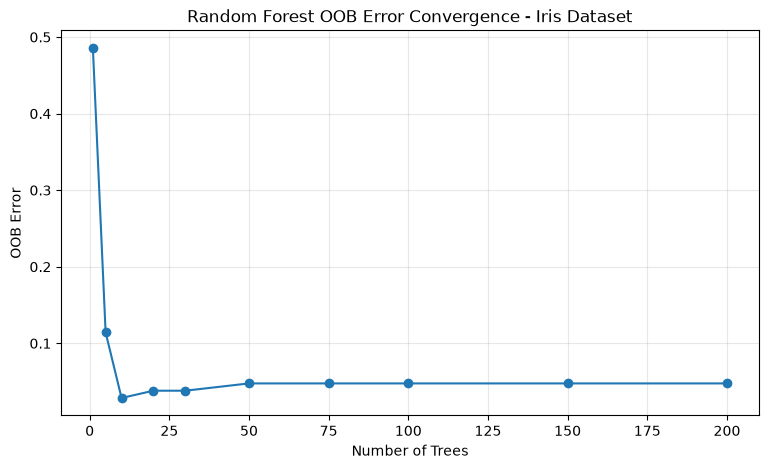

In [22]:
# ============================================================
# 12. PLOT OOB ERROR CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Convergence - Iris Dataset")
plt.grid(True, alpha=0.3)
plt.show()


### Student observation
Look for the region where OOB error becomes relatively stable.

With only 14 students, the OOB curve may jump around considerably. That is a limitation of the very small teaching dataset, not an error in the code.


# Part D — `max_features` Comparison

`max_features` controls how many features are considered when a tree searches for a split.

We compare:

- `sqrt`
- `log2`
- `None` → all features

This demonstrates **feature subsampling**.


In [23]:
# ============================================================
# 13. COMPARE max_features
# ============================================================

max_features_values = ["sqrt", "log2", None]

max_features_results = []

for mf in max_features_values:

    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_features=mf,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    max_features_results.append({
        "max_features": str(mf),
        "Train_Accuracy": accuracy_score(y_train, train_pred),
        "Validation_Accuracy": accuracy_score(y_val, val_pred),
        "OOB_Accuracy": model.oob_score_,
        "OOB_Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(max_features_results)

display(max_features_df.round(4))


,max_features,Train_Accuracy,Validation_Accuracy,OOB_Accuracy,OOB_Error
0,sqrt,1.0,0.8889,0.9524,0.0476
1,log2,1.0,0.8889,0.9524,0.0476
2,None,1.0,0.9333,0.9524,0.0476


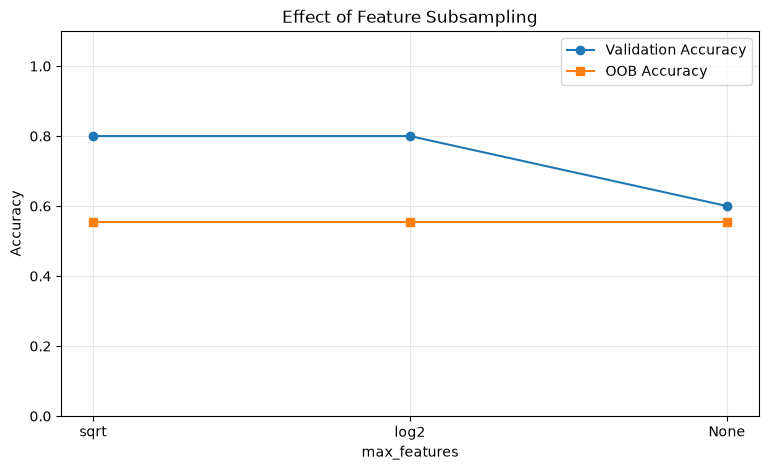

In [ ]:
# ============================================================
# 14. PLOT max_features COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()


# Part E — Manual Bootstrap Bagging

### Layman idea

Suppose the training set has students:

`S1, S2, S3, S4, ...`

For one tree we randomly select students **with replacement**.

A bootstrap sample might look like:

`S1, S3, S3, S5, S7, S1, ...`

Another tree receives a different sample.

This section manually demonstrates the idea before using scikit-learn's BaggingClassifier.


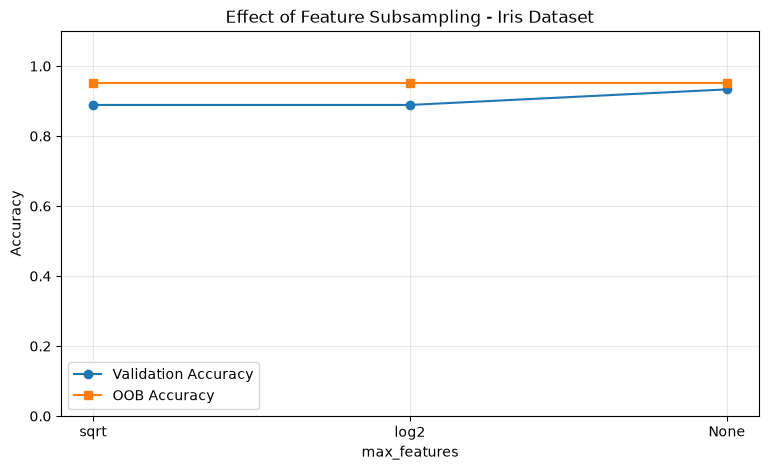

In [24]:
# ============================================================
# 14. PLOT max_features COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling - Iris Dataset")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# ============================================================
# 16. MANUAL BAGGING: TRAIN MANY BOOTSTRAPPED TREES
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []

rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):

    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    # Iris dataset uses NumPy arrays
    X_boot = X_train[sample_indices]
    y_boot = y_train[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(X_boot, y_boot)

    manual_trees.append(tree)

print(f"{N_MANUAL_TREES} manually bagged trees trained.")

50 manually bagged trees trained.


In [ ]:
# ============================================================
# 15. MANUAL BOOTSTRAP SAMPLE
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    np.arange(len(X_train)),
    size=len(X_train),
    replace=True
)

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    np.unique(indices)
)

print("Bootstrap indices:")
print(indices)

print("\nUnique selected rows:")
print(np.unique(indices))

print("\nOOB row indices:")
print(oob_indices)

print("\nTotal bootstrap observations:", len(indices))
print("Unique observations:", len(np.unique(indices)))
print("OOB observations:", len(oob_indices)

In [34]:
# ============================================================
# 16. MANUAL BAGGING: TRAIN MANY BOOTSTRAPPED TREES
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []

rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):

    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    # Iris dataset uses NumPy arrays
    X_boot = X_train[sample_indices]
    y_boot = y_train[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(X_boot, y_boot)

    manual_trees.append(tree)

print(f"{N_MANUAL_TREES} manually bagged trees trained.")

50 manually bagged trees trained.


In [35]:
# ============================================================
# 17. MANUAL BAGGING: MAJORITY VOTE
# ============================================================

# Each tree predicts the validation samples
tree_predictions = np.array([
    tree.predict(X_val)
    for tree in manual_trees
])

# Majority vote across all trees
manual_bagging_pred = []

for sample_predictions in tree_predictions.T:

    counts = np.bincount(
        sample_predictions,
        minlength=len(iris.target_names)
    )

    manual_bagging_pred.append(
        np.argmax(counts)
    )

manual_bagging_pred = np.array(manual_bagging_pred)

# Calculate validation accuracy
manual_bagging_acc = accuracy_score(
    y_val,
    manual_bagging_pred
)

print(
    "Manual Bootstrap Bagging Validation Accuracy:",
    f"{manual_bagging_acc:.4f}"
)

Manual Bootstrap Bagging Validation Accuracy: 0.9556


# Part F — scikit-learn BaggingClassifier

The previous cells showed the mechanism manually.

Now `BaggingClassifier` automates bootstrap sampling and combines the tree predictions.

**Bagging vs Random Forest:**
- Bagging mainly uses bootstrap samples.
- Random Forest additionally introduces random feature selection at splits.


In [ ]:
# ============================================================
# 18. BAGGING CLASSIFIER
# ============================================================

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

bagging_train_pred = bagging.predict(X_train)
bagging_val_pred = bagging.predict(X_val)

print("BAGGING PERFORMANCE")
print("=" * 50)
print(f"Training Accuracy   : {accuracy_score(y_train, bagging_train_pred):.4f}")
print(f"Validation Accuracy : {accuracy_score(y_val, bagging_val_pred):.4f}"

c:\Users\Arnav\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\ensemble\_bootstrap.py:64: UserWarning: Using the fractional value max_samples=1.0 when the number of samples is 9 results in a low number (9) of bootstrap samples. We recommend passing `max_samples` as an integer instead.
  warn(


BAGGING PERFORMANCE
Training Accuracy   : 1.0000
Validation Accuracy : 0.6000


# Part G — Permutation Importance

### Layman idea

1. Measure normal validation accuracy.
2. Shuffle one feature.
3. Predict again.
4. If accuracy drops a lot, that feature was important.
5. If accuracy changes little, that feature contributed less.

We calculate it on the validation set.


In [37]:
# ============================================================
# 19. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": iris.feature_names,
    "Mean_Importance": perm.importances_mean,
    "Std_Importance": perm.importances_std
}).sort_values(
    "Mean_Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.round(4))


,Feature,Mean_Importance,Std_Importance
0,petal length (cm),0.1607,0.0400
1,petal width (cm),0.1370,0.0340
2,sepal width (cm),-0.0030,0.0076
3,sepal length (cm),-0.0185,0.0142


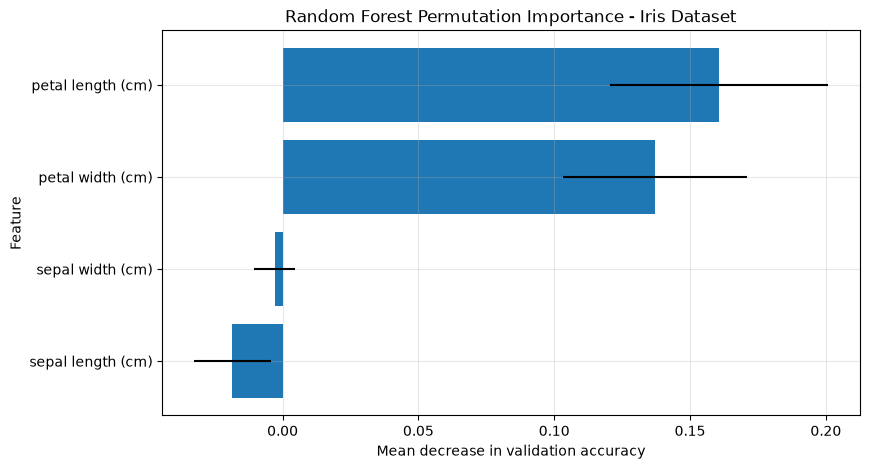

In [38]:
# ============================================================
# 20. PLOT PERMUTATION IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Mean_Importance"],
    xerr=importance_df["Std_Importance"]
)

plt.xlabel("Mean decrease in validation accuracy")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance - Iris Dataset")

plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

# Part H — `rf_vs_single_tree()` Function

This is the main reusable experiment.

The function receives:

`X_train, y_train, X_val, y_val, n_estimators_list`

and returns:

`[n_estimators, RF_val_acc, DT_val_acc, OOB_acc]`

It also plots the requested **three lines**.


In [39]:
X_train
y_train
X_val
y_val

array([2, 1, 2, 1, 2, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 2, 2, 1, 0, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2,
       1])

In [41]:
# ============================================================
# 21. rf_vs_single_tree() FUNCTION
# ============================================================

def rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
):

    results = []

    # --------------------------------------------------------
    # Train one fixed Decision Tree
    # --------------------------------------------------------

    dt = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )

    dt.fit(X_train, y_train)

    dt_val_acc = accuracy_score(
        y_val,
        dt.predict(X_val)
    )

    # --------------------------------------------------------
    # Train Random Forests with different numbers of trees
    # --------------------------------------------------------

    for n in n_estimators_list:

        rf_model = RandomForestClassifier(
            n_estimators=n,
            criterion="entropy",
            max_features="sqrt",
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        rf_val_acc = accuracy_score(
            y_val,
            rf_model.predict(X_val)
        )

        oob_acc = rf_model.oob_score_

        results.append({
            "n_estimators": n,
            "RF_val_acc": rf_val_acc,
            "DT_val_acc": dt_val_acc,
            "OOB_acc": oob_acc
        })

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Plot comparison
    # --------------------------------------------------------

    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["n_estimators"],
        results_df["RF_val_acc"],
        marker="o",
        label="Random Forest Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["DT_val_acc"],
        marker="s",
        label="Single Decision Tree Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["OOB_acc"],
        marker="^",
        label="Random Forest OOB Accuracy"
    )

    plt.xlabel("Number of Trees")
    plt.ylabel("Accuracy")
    plt.title("Random Forest vs Decision Tree - Iris Dataset")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df

c:\Users\Arnav\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\Arnav\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


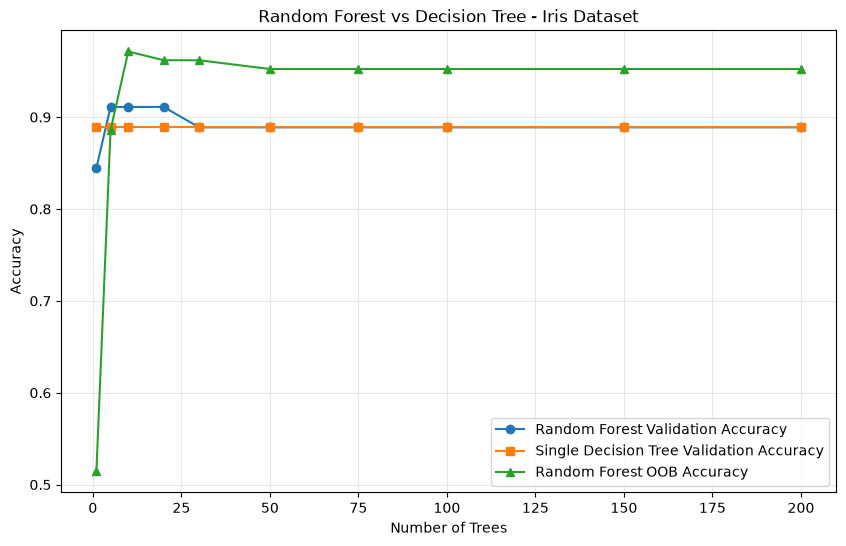

,n_estimators,RF_val_acc,DT_val_acc,OOB_acc
0,1,0.8444,0.8889,0.5143
1,5,0.9111,0.8889,0.8857
2,10,0.9111,0.8889,0.9714
3,20,0.9111,0.8889,0.9619
4,30,0.8889,0.8889,0.9619
5,50,0.8889,0.8889,0.9524
6,75,0.8889,0.8889,0.9524
7,100,0.8889,0.8889,0.9524
8,150,0.8889,0.8889,0.9524
9,200,0.8889,0.8889,0.9524


In [42]:
# ============================================================
# 22. RUN THE FUNCTION
# ============================================================

n_estimators_list = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

rf_dt_results = rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
)

display(rf_dt_results.round(4))


In [43]:
# ============================================================
# 23. BEST RANDOM FOREST SIZE
# ============================================================

best_rf_row = rf_dt_results.loc[
    rf_dt_results["RF_val_acc"].idxmax()
]

print("Best Random Forest result based on validation accuracy:")
print("=" * 65)
print(best_rf_row.to_string())

Best Random Forest result based on validation accuracy:
n_estimators    5.000000
RF_val_acc      0.911111
DT_val_acc      0.888889
OOB_acc         0.885714


# Part I — Overall Model Comparison

In [44]:
# ============================================================
# 24. OVERALL COMPARISON
# ============================================================

overall_comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Random Forest",
        "Manual Bootstrap Bagging",
        "BaggingClassifier"
    ],
    "Training Accuracy": [
        accuracy_score(y_train, dt_train_pred),
        accuracy_score(y_train, rf_train_pred),
        np.nan,
        accuracy_score(y_train, bagging_train_pred)
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, dt_val_pred),
        accuracy_score(y_val, rf_val_pred),
        manual_bagging_acc,
        accuracy_score(y_val, bagging_val_pred)
    ],
    "OOB Accuracy": [
        np.nan,
        rf.oob_score_,
        np.nan,
        np.nan
    ]
})

display(overall_comparison.round(4))


,Model,Training Accuracy,Validation Accuracy,OOB Accuracy
0,Single Decision Tree,1.0,0.8889,NaN
1,Random Forest,1.0,0.8889,0.9524
2,Manual Bootstrap Bagging,NaN,0.9556,NaN
3,BaggingClassifier,1.0,0.9556,NaN


# Final Learning Summary

Students should be able to explain:

1. How Random Forest combines many Decision Trees.
2. How bootstrap sampling creates different training sets.
3. What OOB observations are.
4. How OOB error changes as the number of trees increases.
5. What `max_features` means.
6. Why feature subsampling makes trees different.
7. How manual bagging works.
8. How permutation importance identifies influential features.
9. Whether Random Forest improves over a single Decision Tree on the validation data.
10. Why results from only 14 students should be interpreted as a classroom demonstration rather than a reliable real-world performance estimate.
